<a href="https://colab.research.google.com/github/linda-bsharat/telco-customer-churn-prediction/blob/main/notebooks/%2003_model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#03 - Model Building & Evaluation

In this stage of the project, we build and evaluate a machine learning model to predict customer churn.  
The goal is to train a model that can identify customers who are likely to leave the company.

The main steps in this stage include:

1. Preparing the dataset for machine learning.
2. Splitting the data into training and testing sets.
3. Training a machine learning model.
4. Making predictions on the test data.
5. Evaluating the model's performance using different metrics.


##**1. Import Libraries**

In [11]:
# Import required libraries for machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier


## **2. Load Clean Dataset**

In [12]:
# Load the cleaned dataset

df = pd.read_csv("https://raw.githubusercontent.com/linda-bsharat/telco-customer-churn-prediction/refs/heads/main/data/telco_customer_data_cleaned.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices
0,1,0,0,1,3.0,1,2,0,0,0,...,205.83,1,0,0,0,1,1,0,51.457500,1
1,1,1,1,0,2.0,1,2,1,0,0,...,46.30,0,1,0,0,0,1,0,15.433333,2
2,0,0,0,0,42.0,1,2,1,0,1,...,1790.46,1,0,0,1,0,0,0,41.638605,4
3,0,0,0,1,40.0,1,2,2,0,0,...,3001.60,0,0,0,1,0,0,0,73.209756,2
4,1,1,1,1,17.0,1,1,2,1,0,...,380.46,1,0,0,1,0,0,0,21.136667,3


##**3. Define Features and Target**

In [13]:
# Define features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Check
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (67376, 26)
Target shape: (67376,)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'IsNewCustomer', 'IsLongTermCustomer', 'AvgMonthlyCharge', 'TotalServices']


## **4. Split the Dataset**

We divide the dataset into training and testing sets.
Training data is used to train the model.
Testing data is used to evaluate model performance.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (53900, 26)
Testing set: (13476, 26)


## **5. Logistic Regression Model**

Logistic Regression is commonly used for binary classification problems like churn prediction.

In [15]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])



*   ## **6. Model Predictions**




The trained model predicts churn on the test dataset.

In [16]:
y_pred = pipeline.predict(X_test)



*   ## **7. Model Accuracy**




Accuracy measures how many predictions were correct.

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7704066488572276
Precision: 0.700995452869608
Recall: 0.8961508248232521
F1 Score: 0.7866501172252103




*   ## **8. Confusion Matrix**




Shows how many predictions were correct and incorrect.

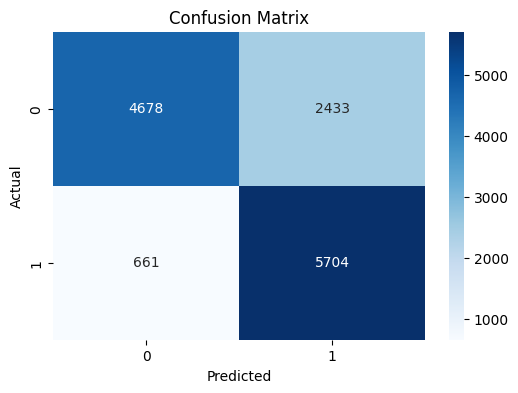

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Random Forest Model

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions.
It is often more powerful than simple models like Logistic Regression.[link text](https://)

In [31]:
# Initialize Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train model

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [32]:
# Predict churn

y_pred_rf = rf_model.predict(X_test)

In [33]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7635054912436925


In [34]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[4765 2346]
 [ 841 5524]]


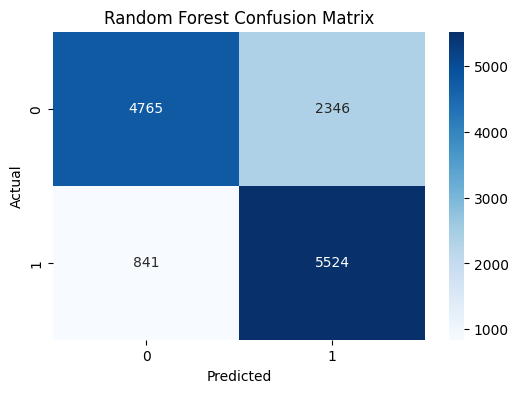

In [36]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()